# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

Dataset extracted to: /content/devnagari_data
Processing folder: /content/devnagari_data/DevanagariHandwrittenDigitDataset/Train
  Loaded 1700 images from digit_0
  Loaded 1700 images from digit_1
  Loaded 1700 images from digit_2
  Loaded 1700 images from digit_3
  Loaded 1700 images from digit_4
  Loaded 1700 images from digit_5
  Loaded 1700 images from digit_6
  Loaded 1700 images from digit_7
  Loaded 1700 images from digit_8
  Loaded 1700 images from digit_9
Processing folder: /content/devnagari_data/DevanagariHandwrittenDigitDataset/Test
  Loaded 300 images from digit_0
  Loaded 300 images from digit_1
  Loaded 300 images from digit_2
  Loaded 300 images from digit_3
  Loaded 300 images from digit_4
  Loaded 300 images from digit_5
  Loaded 300 images from digit_6
  Loaded 300 images from digit_7
  Loaded 300 images from digit_8
  Loaded 300 images from digit_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9154 - loss: 0.2602 - val_accuracy: 0.9625 - val_loss: 0.1164
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9741 - loss: 0.0824 - val_accuracy: 0.9719 - val_loss: 0.1035
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9815 - loss: 0.0574 - val_accuracy: 0.9819 - val_loss: 0.0720
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9867 - loss: 0.0399 - val_accuracy: 0.9769 - val_loss: 0.0902
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9871 - loss: 0.0399 - val_accuracy: 0.9819 - val_loss: 0.0976
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9872 - loss: 0.0375 - val_accuracy: 0.9806 - val_loss: 0.0764
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9914 - loss: 0.0247 - val_accuracy: 0.9800 - val_loss: 0.0730
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9925 - loss: 0.0222 - val_accurac

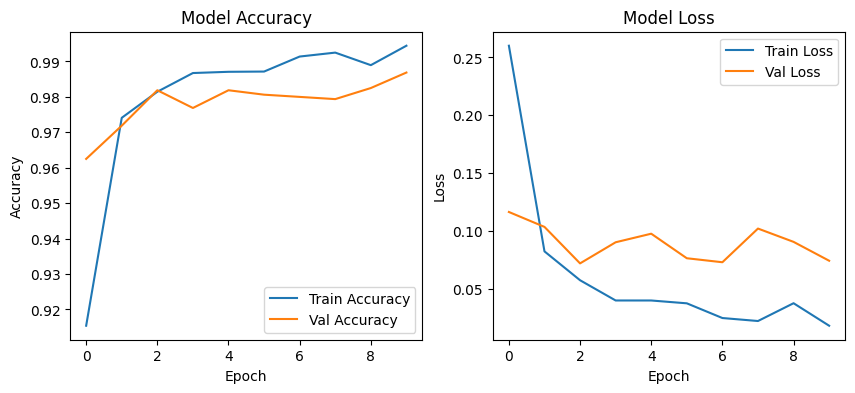

In [5]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import cv2

# --- Question 1: Extract the Dataset ---
# Task: Unzip the provided dataset and explore the directory structure.

zip_path = "/content/Copy of devnagari digit.zip"
extract_path = "/content/devnagari_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

# --- Question 2: Load and Preprocess the Data ---
# Task: Load images, resize them if necessary, and normalize pixel values.

def load_data(base_path):
    images = []
    labels = []
    class_map = {}

    # Walk through the directory to find 'Train' and 'Test' folders wherever they are
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root) in ['Train', 'Test']:
            print(f"Processing folder: {root}")
            subdirs = sorted([d for d in dirs if os.path.isdir(os.path.join(root, d))])

            for subdir in subdirs:
                if subdir not in class_map:
                    class_map[subdir] = len(class_map)

                label = class_map[subdir]
                full_subdir = os.path.join(root, subdir)
                img_count = 0
                for img_name in os.listdir(full_subdir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(full_subdir, img_name)
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            img = cv2.resize(img, (28, 28))
                            images.append(img)
                            labels.append(label)
                            img_count += 1
                if img_count > 0:
                    print(f"  Loaded {img_count} images from {subdir}")

    return np.array(images), np.array(labels)

X, y = load_data(extract_path)

if len(X) == 0:
    raise ValueError("No images were loaded. Please verify the folder names inside the ZIP.")

# Normalization and Reshaping for FCN (Flattening)
X = X.astype("float32") / 255.0
X_flat = X.reshape(X.shape[0], -1)

# One-hot encoding labels
y_cat = keras.utils.to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_cat, test_size=0.2, random_state=42)

# --- Question 3: Build an FCN Model using Keras ---
# Task: Create a Fully Connected Network for classification.

model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(256, activation="relu"),
    layers.Dense(y_cat.shape[1], activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# --- Question 4: Train the Model ---
# Task: Train the model and monitor performance.

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# --- Question 5: Evaluation ---
# Task: Evaluate the model on the test set and plot results.

loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Question 6: Prediction and Visualization
Task: Use the trained model to predict the class of a few test images and visualize the results.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


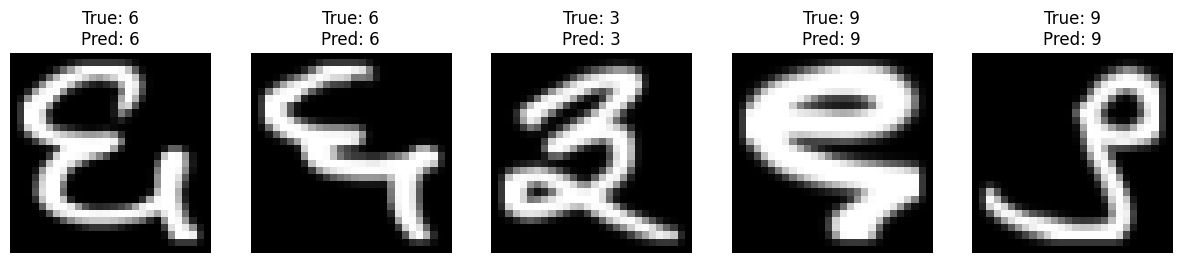

In [6]:
# Select random images from the test set
num_samples = 5
random_indices = np.random.choice(len(X_test), num_samples)
sample_images = X_test[random_indices]
sample_labels = np.argmax(y_test[random_indices], axis=1)

# Make predictions
predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

# Visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {sample_labels[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()

### Question 7: Model Saving
Task: Save the trained Keras model to a file.

In [7]:
# Save the model in Keras format
model_save_path = 'devnagari_digit_model.keras'
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to devnagari_digit_model.keras
